In [2]:
import sys
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
sys.path.append('../bin')
from bin.functions import *
from bin.permutation import *
from bin.markov_permutation import *
from bin.entropy import *
np.seterr(all = 'ignore')
import warnings
warnings.filterwarnings('ignore')

In [72]:
def count_cut_permutation(ts, window):
    if window == 3:
        c_p = count_permutation(ts, 3)
        return [c_p[0], c_p[1]+c_p[3], c_p[2]+c_p[4], c_p[5]]
    if window == 4:
        c_p = count_permutation(ts, 4)
        return [c_p[0], c_p[1]+c_p[3]+c_p[9], c_p[2]+c_p[4]+c_p[8]+c_p[10]+c_p[16], c_p[5]+c_p[11]+c_p[17], c_p[6]+c_p[12]+c_p[18], c_p[7]+c_p[13]+c_p[15]+c_p[19]+c_p[21], c_p[14]+c_p[22]+c_p[20], c_p[23]]
def new_permutation_entropy(ts, window):
    return entropy(count_cut_permutation(ts,window))
def new_permutation_series(ts: pd.Series, window: int) -> pd.Series:
    r = list(range(window))
    permutation_list = list(it.permutations(r))
    pseries = []
    real_ts = remove_consecutive_duplicates(ts.copy())
    for i in range(real_ts.size - window + 1):
        slice_df = real_ts.copy().iloc[i:i + window]
        sort_slice = slice_df.copy().sort_values()
        for j in range(window):
            slice_df[slice_df[slice_df == sort_slice.iloc[j]].first_valid_index()] = j
        pseries.append(permutation_list.index(tuple(slice_df.tolist())))
    if window == 3:
        change_dict = {0:0, 1:1, 2:2, 3:1, 4:2, 5:3}
        return pd.Series(pseries).map(change_dict)
    if window == 4:
        change_dict = {0:0, 1:1, 2:2, 3:1, 9:1, 4:2, 8:2, 10:2, 16:2, 5:3, 11:3, 17:3, 6:4, 12:4, 18:4, 7:5, 13:5, 15:5, 19:5, 21:5, 14:6, 22:6, 20:6, 23:7}
        return pd.Series(pseries).map(change_dict)

In [14]:
ts = generate_rw(1000)

In [15]:
p_s = permutation_series(ts, 3)
p_s

0      0
1      0
2      0
3      0
4      3
      ..
993    4
994    0
995    0
996    0
997    1
Length: 998, dtype: int64

<Axes: ylabel='Count'>

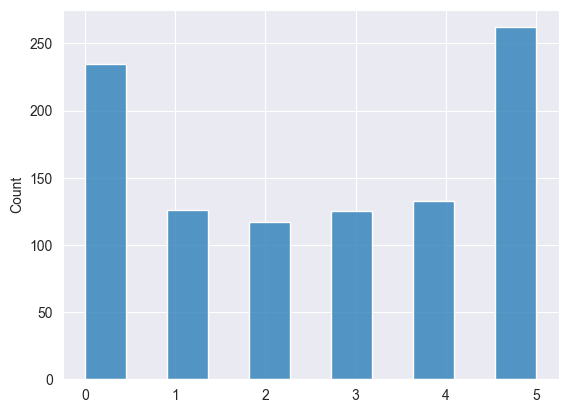

In [16]:
sns.histplot(p_s)

In [17]:
p_s1 = new_permutation_series(ts, 3)
p_s1

0      0
1      0
2      0
3      0
4      1
      ..
993    2
994    0
995    0
996    0
997    1
Length: 998, dtype: int64

<Axes: ylabel='Count'>

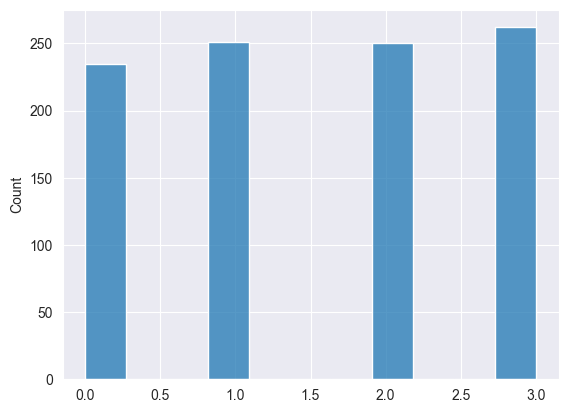

In [18]:
sns.histplot(p_s1)

<Axes: ylabel='Count'>

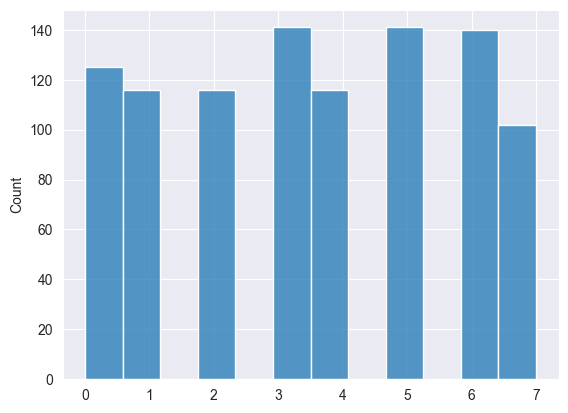

In [28]:
sns.histplot(new_permutation_series(generate_rw(1000), 4))

In [40]:
new_permutation_series(generate_rw(1000), 4).value_counts()

3    138
6    138
4    131
1    131
5    120
7    115
2    113
0    111
Name: count, dtype: int64

In [73]:
ts1 = generate_rw(1000)
p_s2 = new_permutation_series(ts1,4)
matrix = compute_transition_matrix(p_s2)
matrix

array([[0.48305085, 0.51694915, 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.46153846, 0.53846154, 0.        ,
        0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.47619048,
        0.52380952, 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.58914729, 0.41085271],
       [0.46923077, 0.53076923, 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.536     , 0.464     , 0.        ,
        0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.54263566,
        0.45736434, 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.48623853, 0.51376147]])

In [74]:
print(new_permutation_entropy(ts1, 4))
entropy_rate(matrix)

2.997676148445532


(2.9975978533797205, 0.9938922778748747)

In [75]:
ts2 = generate_arma(10, 5, 1000)
p_s3 = new_permutation_series(ts2,4)
matrix = compute_transition_matrix(p_s3)
matrix

array([[0.65034965, 0.34965035, 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.69090909, 0.30909091, 0.        ,
        0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.16814159,
        0.83185841, 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.16666667, 0.83333333],
       [0.90909091, 0.09090909, 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.81385281, 0.18614719, 0.        ,
        0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.28813559,
        0.71186441, 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.2994012 , 0.7005988 ]])

In [76]:
print(new_permutation_entropy(ts1, 4))
entropy_rate(matrix)

2.997676148445532


(2.7581559028730736, 0.6582368118673763)

In [77]:
#TODO показать что перестановки во временном ряду лучше считать с помощью стационарного распределения марковской цепи, а не по относительной частоте

In [78]:
def new_permutation_entropy_rate(time_series: pd.Series, window: int) -> float:
    permutation = new_permutation_series(time_series, window)
    transition_matrix = compute_transition_matrix(permutation)

    matrix_dot = transition_matrix.copy()
    transition_probabilities = matrix_dot.copy()
    for _ in range(5):
        matrix_dot = np.dot(matrix_dot, matrix_dot)
    stationary_distribution = np.mean(matrix_dot, axis=0)

    # Normalize the stationary distribution
    stationary_distribution /= stationary_distribution.sum()

    # Compute entropy rate
    tr_ent_rate = -np.sum(np.nan_to_num(
        stationary_distribution * np.sum(np.nan_to_num(transition_probabilities * np.log2(transition_probabilities)),
                                         axis=0)))
    return tr_ent_rate

In [79]:
def create_dataset_df(num_series=100000, series_length=1000):
    """
    Создание датасета, содержащего временные ряды разных типов в виде DataFrame.
    
    Параметры:
    - num_series: int, количество временных рядов каждого типа
    - series_length: int, длина каждого временного ряда
    
    Возвращает:
    - dataset: dict, содержащий временные ряды разных типов в виде DataFrame
    """
    dataset = {}
    
    # Создание авторегрессионных временных рядов с малой памятью
    ar2_series = []
    for _ in range(num_series):
        time_series = np.random.randint(-100, 100) + generate_arma(p=2, q=0, n=series_length)
        ar2_series.append(time_series)
    dataset['ar2'] = pd.DataFrame(ar2_series)
    
    # Создание авторегрессионных временных рядов с большой памятью
    arma_series = []
    for _ in range(num_series):
        time_series = np.random.randint(-100, 100) + generate_arma(p=10, q=5, n=series_length)
        arma_series.append(time_series)
    dataset['arma'] = pd.DataFrame(arma_series)
    
    # Создание мультифрактальных временных рядов
    multifractal_series = []
    for _ in range(num_series):
        time_series = generate_multifractal(series_length, H=np.random.rand())
        multifractal_series.append(time_series)
    dataset['multifractal'] = pd.DataFrame(multifractal_series)
    
    # Создание трендовых временных рядов
    cos_series = []
    ts_n_series = []
    for _ in range(num_series):
        ts_n, time_series = generate_trend_series(length=series_length, trend_koef=np.random.uniform(low=0, high=0.6), ampl=np.random.uniform(low=0, high=1.5), seasonality_period=12, seasonality_aplitude=np.random.uniform(low=0, high=0.5), sigma=np.random.uniform(low=0.2,high=0.5))
        ts_n_series.append(ts_n)
        cos_series.append(time_series)
    dataset['trend_cos'] = pd.DataFrame(cos_series)
    
    # Создание случайных блужданий
    rand_wolk_series = []

    for _ in range(num_series):
        time_series = np.random.uniform(low=-50, high=50) + generate_rw(series_length)
        rand_wolk_series.append(time_series)
    dataset['random_walk'] = pd.DataFrame(rand_wolk_series)
    
    return dataset, pd.DataFrame(ts_n_series)

In [80]:
def calculate_characteristics(dataset_df):
    """
    Вычисление характеристик для каждого временного ряда в датасете и сохранение их в датафрейме.
    
    Параметры:
    - dataset_df: dict, содержащий временные ряды разных типов в виде DataFrame
    
    Возвращает:
    - characteristics_df: DataFrame, содержащий характеристики для каждого временного ряда
    """
    characteristics = {}
    
    # Вычисление характеристик для каждого типа временного ряда
    for key, df in dataset_df.items():
        print(key)
        characteristics[key + '_new_ent_rate3'] = df.apply(new_permutation_entropy_rate, args=(3,), axis=1)
        characteristics[key + '_new_ent_rate4'] = df.apply(new_permutation_entropy_rate, args=(4,), axis=1)
        
        
    # Создание датафрейма с характеристиками
    characteristics_df = pd.DataFrame(characteristics)
    
    return characteristics_df

In [83]:
dataset_df, trend_series_wo_noise = create_dataset_df(num_series=50, series_length=500)

In [84]:
characteristics_df = calculate_characteristics(dataset_df)

ar2
arma
multifractal
trend_cos
random_walk


Text(0, 0.5, 'Density')

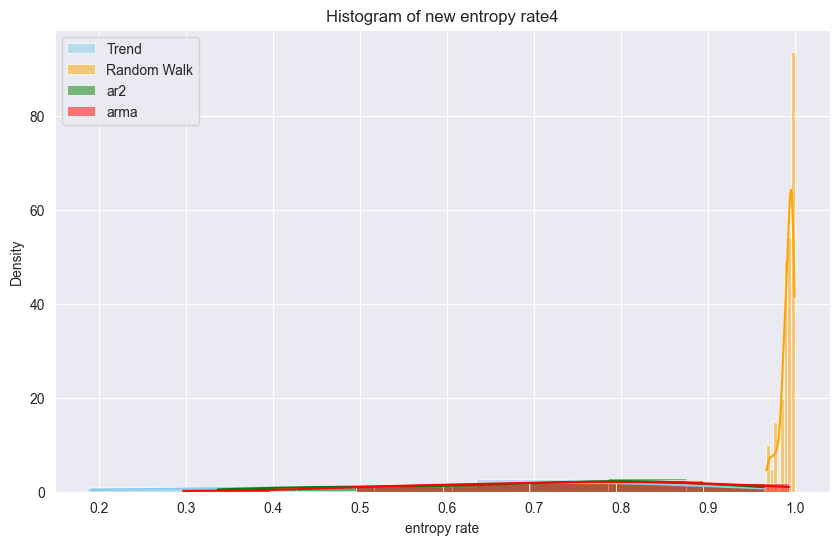

In [87]:
plt.figure(figsize=(10, 6))
    
# Гистограмма
sns.histplot(characteristics_df['trend_cosnew_ent_rate3'], kde=True, color="skyblue", stat="density", linewidth=0.5, label=f'Trend')
sns.histplot(characteristics_df['random_walknew_ent_rate3'], kde=True, color="orange", stat="density", linewidth=0.5, label=f'Random Walk')
sns.histplot(characteristics_df['ar2new_ent_rate3'], kde=True, color="green", stat="density", linewidth=0.5, label=f'ar2')
sns.histplot(characteristics_df['armanew_ent_rate3'], kde=True, color="red", stat="density", linewidth=0.5, label=f'arma')
#sns.histplot(characteristics_df['multifractalnew_ent3'], kde=True, color="yellow", stat="density", linewidth=0.5, label=f'multifractal')
plt.legend()
plt.title(f'Histogram of new entropy rate4')
plt.xlabel(f'entropy rate')
plt.ylabel('Density')

Text(0, 0.5, 'Density')

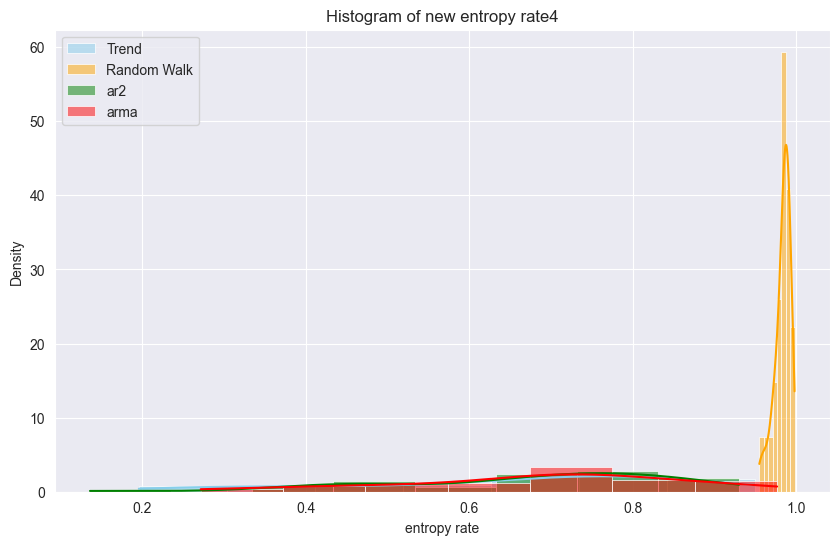

In [88]:
plt.figure(figsize=(10, 6))
    
# Гистограмма
sns.histplot(characteristics_df['trend_cosnew_ent_rate4'], kde=True, color="skyblue", stat="density", linewidth=0.5, label=f'Trend')
sns.histplot(characteristics_df['random_walknew_ent_rate4'], kde=True, color="orange", stat="density", linewidth=0.5, label=f'Random Walk')
sns.histplot(characteristics_df['ar2new_ent_rate4'], kde=True, color="green", stat="density", linewidth=0.5, label=f'ar2')
sns.histplot(characteristics_df['armanew_ent_rate4'], kde=True, color="red", stat="density", linewidth=0.5, label=f'arma')
#sns.histplot(characteristics_df['multifractalnew_ent3'], kde=True, color="yellow", stat="density", linewidth=0.5, label=f'multifractal')
plt.legend()
plt.title(f'Histogram of new entropy rate4')
plt.xlabel(f'entropy rate')
plt.ylabel('Density')

In [89]:
def make_forecast(dataset, forecast_func, forecast_length):
    """
    Make forecasts for each time series in the dataset.

    Parameters:
        dataset (pandas.DataFrame): Input dataset where each row represents a time series.
        forecast_func (function): Function for making forecasts. This function should take a time series
                                  as input and return the forecasted values.
        forecast_length (int): Length of the forecast horizon.

    Returns:
        pandas.DataFrame: DataFrame containing the forecasted values.
    """
    # Create an empty DataFrame to store the forecasted values
    forecasted_dataset = pd.DataFrame(columns=dataset.columns[len(dataset.columns)-forecast_length:])

    # Iterate over each row (time series) in the dataset
    for index, row in dataset.iterrows():
        # Extract the time series
        time_series = row.values
        
        # Make the forecast using the provided function
        forecast = forecast_func(time_series[:len(time_series) - forecast_length], forecast_length)
        
        # Create a new column in the forecasted dataset with the forecasted values
        forecasted_dataset.loc[index] = forecast
    
    return forecasted_dataset

In [90]:
predictions = {"ar2": make_forecast(dataset_df["ar2"], ar2_forecast, 30),
               "arma": make_forecast(dataset_df["arma"], arma_forecast, 30),
               "multifractal": make_forecast(dataset_df["multifractal"], naive_forecast, 30),
               "random_walk": make_forecast(dataset_df["random_walk"], naive_forecast, 30),
               "trend_cos": trend_series_wo_noise.iloc[:, [i for i in range(trend_series_wo_noise.shape[1] - 30, trend_series_wo_noise.shape[1])]]}

In [91]:
from sklearn.metrics import mean_squared_error

def calculate_metrics(real_dataset, predicted_dataset):
    """
    Calculate SMAPE, MASE, and RMSE metrics for each pair of time series in the datasets.

    Parameters:
        real_dataset (pandas.DataFrame): DataFrame containing real values, where each row represents a time series.
        predicted_dataset (pandas.DataFrame): DataFrame containing predicted values, where each row represents a time series.
        
    Returns:
        pandas.DataFrame: DataFrame containing SMAPE, MASE, and RMSE metrics for each pair of time series.
    """
    # Initialize lists to store the metrics
    smape_scores = []
    mase_scores = []
    rmse_scores = []

    # Iterate over each pair of real and predicted time series
    for real_series, predicted_series in zip(real_dataset.values, predicted_dataset.values):
        # Calculate SMAPE
        smape = symmetric_mean_absolute_percentage_error(real_series[len(real_series) - len(predicted_series):], predicted_series)
        smape_scores.append(smape)

        # Calculate RMSE
        rmse = np.sqrt(mean_squared_error(real_series[len(real_series) - len(predicted_series):], predicted_series))
        rmse_scores.append(rmse)

        # Calculate MASE
        mase = mean_absolute_scaled_error(real_series[:len(real_series) - len(predicted_series)], real_series[len(real_series) - len(predicted_series):], predicted_series, 1)
        mase_scores.append(mase)

    # Create a DataFrame to store the metrics
    metrics_df = pd.DataFrame({
        'SMAPE': smape_scores,
        'MASE': mase_scores,
        'RMSE': rmse_scores
    })

    return metrics_df

In [92]:
metrics_df = {'ar2': calculate_metrics(dataset_df["ar2"], predictions['ar2']),
              'arma': calculate_metrics(dataset_df["arma"], predictions['arma']),
              'multifractal': calculate_metrics(dataset_df["multifractal"], predictions['multifractal']),
              'random_walk': calculate_metrics(dataset_df["random_walk"], predictions['random_walk']),
              'trend_cos': calculate_metrics(dataset_df["trend_cos"], predictions['trend_cos'])}

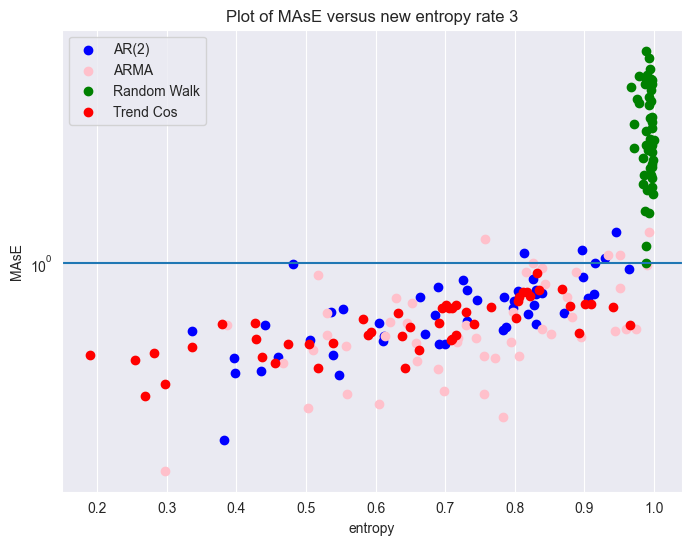

In [93]:
plt.figure(figsize=(8, 6))
plt.scatter(characteristics_df["ar2new_ent_rate3"], metrics_df['ar2']['MASE'], color='blue', label='AR(2)')
plt.scatter(characteristics_df["armanew_ent_rate3"], metrics_df['arma']['MASE'], color='pink', label='ARMA')
plt.scatter(characteristics_df["random_walknew_ent_rate3"], metrics_df['random_walk']['MASE'], color='green', label='Random Walk')
#plt.scatter(metrics_df['multifractal']['SMAPE'], characteristics_df["multifractal_perm_ent4"], color='orange', label='Multifractal')
plt.scatter(characteristics_df["trend_cosnew_ent_rate3"], metrics_df['trend_cos']['MASE'], color='red', label='Trend Cos')
plt.title('Plot of MAsE versus new entropy rate 3')
plt.axhline(y=1)
plt.xlabel('entropy')
plt.ylabel('MAsE')
plt.semilogy()
plt.grid(True)
plt.legend()
plt.show()
# plt.savefig(f'perm_ent3_MASE.png', bbox_inches='tight')
# plt.close()

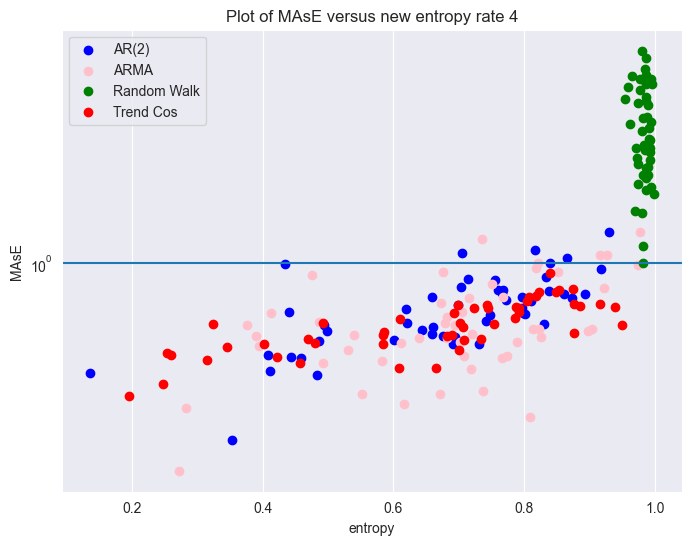

In [94]:
plt.figure(figsize=(8, 6))
plt.scatter(characteristics_df["ar2new_ent_rate4"], metrics_df['ar2']['MASE'], color='blue', label='AR(2)')
plt.scatter(characteristics_df["armanew_ent_rate4"], metrics_df['arma']['MASE'], color='pink', label='ARMA')
plt.scatter(characteristics_df["random_walknew_ent_rate4"], metrics_df['random_walk']['MASE'], color='green', label='Random Walk')
#plt.scatter(metrics_df['multifractal']['SMAPE'], characteristics_df["multifractal_perm_ent4"], color='orange', label='Multifractal')
plt.scatter(characteristics_df["trend_cosnew_ent_rate4"], metrics_df['trend_cos']['MASE'], color='red', label='Trend Cos')
plt.title('Plot of MAsE versus new entropy rate 4')
plt.axhline(y=1)
plt.xlabel('entropy')
plt.ylabel('MAsE')
plt.semilogy()
plt.grid(True)
plt.legend()
plt.show()
# plt.savefig(f'perm_ent3_MASE.png', bbox_inches='tight')
# plt.close()

In [95]:
perm_q = pd.read_csv("../src/features/quater_ent_norm4.csv", index_col=0)

In [96]:
input_file = "../../../Analis/predan_inactive/src/M4-methods/Dataset/Train/Quarterly-train.csv"
with open(input_file, 'r') as file:
    # Убираем кавычки из каждой строки
    lines = [line.replace('"', '') for line in file]

st = "".join(lines)
output_file = "output.csv"
f = open(output_file, "w")
f.write(st)
f.close()
df_q = pd.read_csv(output_file, index_col=0)
df_q.head()

,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,...,V858,V859,V860,V861,V862,V863,V864,V865,V866,V867
V1,,,,,,,,,,,,,,,,,,,,,
Q1,7407.412314,7528.566074,7374.709225,7395.514848,7654.007989,7686.847835,7578.190743,7904.376716,7744.049254,7889.909013,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Q2,7552.454619,7541.774571,7466.568336,7550.333354,8067.131522,8063.701017,7901.029312,8155.387316,8031.010328,8023.240005,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Q3,8463.842193,8366.102309,8269.502192,8256.985325,8726.917647,8733.243591,8664.260087,8717.394568,8662.139727,8629.101896,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Q4,8498.941194,8409.926442,8391.441381,8292.860310,8798.521118,8753.990355,8740.062556,8695.540651,8627.447488,8525.993424,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Q5,1835.000000,2322.000000,3059.000000,1883.000000,1896.000000,2060.000000,2764.000000,1743.000000,1561.000000,1934.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [97]:
new_ent_rate = pd.DataFrame(columns=["new_ent_rate3", "new_ent_rate4"])
for index, row in df_q.iterrows():
    if int(index[1:]) % 100 == 0:
        print(int(index[1:]))
    ts = row.dropna()
    ent3 = new_permutation_entropy_rate(ts,3)
    ent4 = new_permutation_entropy_rate(ts,4)
    new_ent_rate.loc[index] = [ent3, ent4]

100
200
300
400
500
600
700
800
900
1000
1100
1200
1300
1400
1500
1600
1700
1800
1900
2000
2100
2200
2300
2400
2500
2600
2700
2800
2900
3000
3100
3200
3300
3400
3500
3600
3700
3800
3900
4000
4100
4200
4300
4400
4500
4600
4700
4800
4900
5000
5100
5200
5300
5400
5500
5600
5700
5800
5900
6000
6100
6200
6300
6400
6500
6600
6700
6800
6900
7000
7100
7200
7300
7400
7500
7600
7700
7800
7900
8000
8100
8200
8300
8400
8500
8600
8700
8800
8900
9000
9100
9200
9300
9400
9500
9600
9700
9800
9900
10000
10100
10200
10300
10400
10500
10600
10700
10800
10900
11000
11100
11200
11300
11400
11500
11600
11700
11800
11900
12000
12100
12200
12300
12400
12500
12600
12700
12800
12900
13000
13100
13200
13300
13400
13500
13600
13700
13800
13900
14000
14100
14200
14300
14400
14500
14600
14700
14800
14900
15000
15100
15200
15300
15400
15500
15600
15700
15800
15900
16000
16100
16200
16300
16400
16500
16600
16700
16800
16900
17000
17100
17200
17300
17400
17500
17600
17700
17800
17900
18000
18100
18200
18300
18400
1850

In [99]:
new_ent_rate.head()

,new_ent_rate3,new_ent_rate4
Q1,0.849807,0.638104
Q2,0.724374,0.568575
Q3,0.664585,0.440070
Q4,0.496839,0.062203
Q5,0.289868,0.118686


In [100]:
q_df = pd.read_csv("../src/features/quaterly_with_ent_rate4.csv", index_col=0)
q_df.head()

,ent_rate4,value__sum_values,"value__change_quantiles__f_agg_""var""__isabs_False__qh_1.0__ql_0.2","value__change_quantiles__f_agg_""mean""__isabs_False__qh_0.8__ql_0.4","value__change_quantiles__f_agg_""var""__isabs_False__qh_1.0__ql_0.8","value__augmented_dickey_fuller__attr_""usedlag""__autolag_""AIC""",value__mean_n_absolute_max__number_of_maxima_7,value__quantile__q_0.1,value__cid_ce__normalize_True,value__variation_coefficient,"value__agg_autocorrelation__f_agg_""median""__maxlag_40","value__agg_autocorrelation__f_agg_""var""__maxlag_40"
Q1,0.512013,180887.003125,65884.041380,-54.404276,3193.375195,2.0,7718.498974,6635.896052,3.600123,0.059901,0.122784,0.589759
Q2,1.515710,186523.583493,89582.423975,-73.835825,4.708505,5.0,8032.877652,6877.840306,3.278226,0.062034,0.044351,0.667796
Q3,1.231307,199910.304733,203665.440916,-95.932132,2530.594913,0.0,8676.982917,7194.621703,3.654678,0.076222,0.031605,0.477528
Q4,0.034689,202918.966414,94823.450799,-106.462815,208.060089,0.0,8667.572608,7534.424773,3.664353,0.057679,-0.041900,0.467195
Q5,0.380779,89192.000000,435258.553583,163.571429,9216.000000,3.0,2489.428571,908.000000,8.888150,0.337892,-0.055220,0.043032


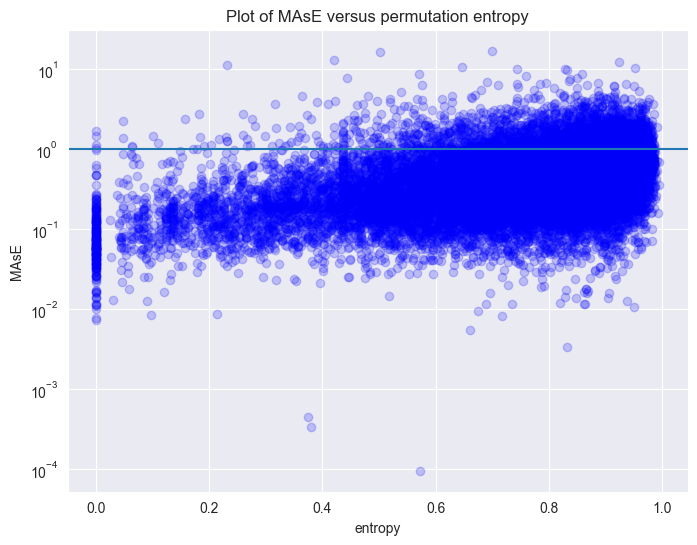

In [101]:
plt.figure(figsize=(8, 6))
plt.scatter(perm_q["perm_ent4"], perm_q['mase'], color='blue', alpha=0.2)
plt.title('Plot of MAsE versus permutation entropy')
plt.axhline(y=1)
plt.xlabel('entropy')
plt.ylabel('MAsE')
plt.semilogy()
plt.grid(True)
plt.show()

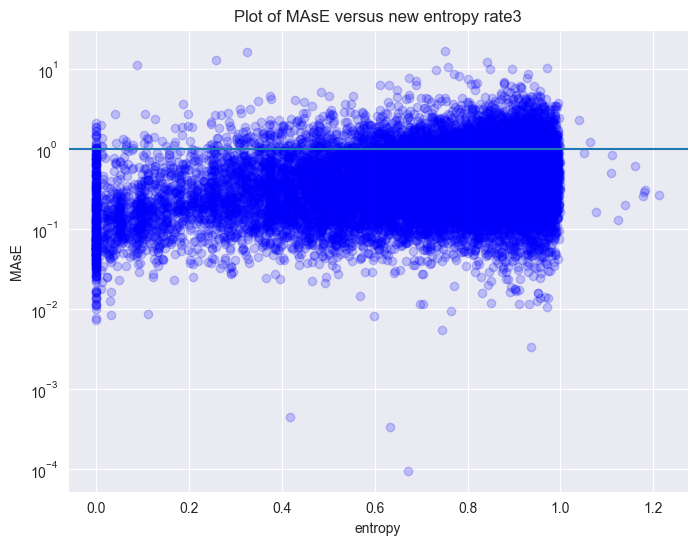

In [102]:
plt.figure(figsize=(8, 6))
plt.scatter(new_ent_rate["new_ent_rate3"], perm_q['mase'], color='blue', alpha=0.2)
plt.title('Plot of MAsE versus new entropy rate3')
plt.axhline(y=1)
plt.xlabel('entropy')
plt.ylabel('MAsE')
plt.semilogy()
plt.grid(True)
plt.show()

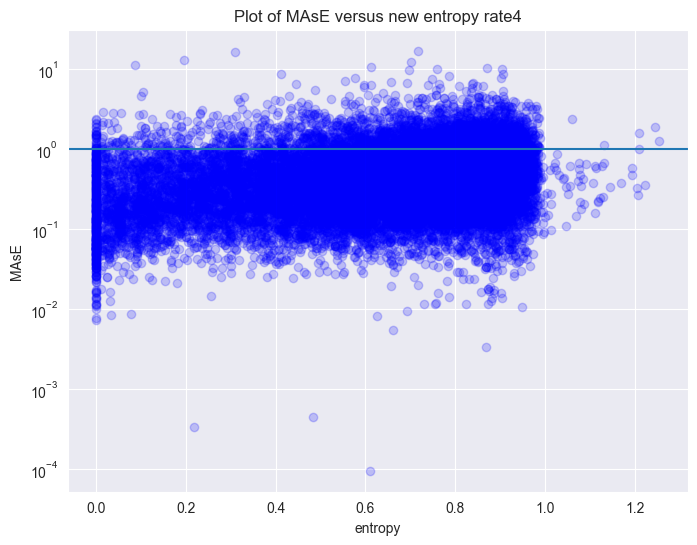

In [103]:
plt.figure(figsize=(8, 6))
plt.scatter(new_ent_rate["new_ent_rate4"], perm_q['mase'], color='blue', alpha=0.2)
plt.title('Plot of MAsE versus new entropy rate4')
plt.axhline(y=1)
plt.xlabel('entropy')
plt.ylabel('MAsE')
plt.semilogy()
plt.grid(True)
plt.show()

In [104]:
ent_df = pd.concat([new_ent_rate, perm_q['perm_ent4'], q_df['ent_rate4']], axis=1)
ent_df.head()

,new_ent_rate3,new_ent_rate4,perm_ent4,ent_rate4
Q1,0.849807,0.638104,0.818860,0.512013
Q2,0.724374,0.568575,0.779205,1.515710
Q3,0.664585,0.440070,0.698904,1.231307
Q4,0.496839,0.062203,0.738144,0.034689
Q5,0.289868,0.118686,0.612547,0.380779


Text(65.34722222222221, 0.5, 'mase')

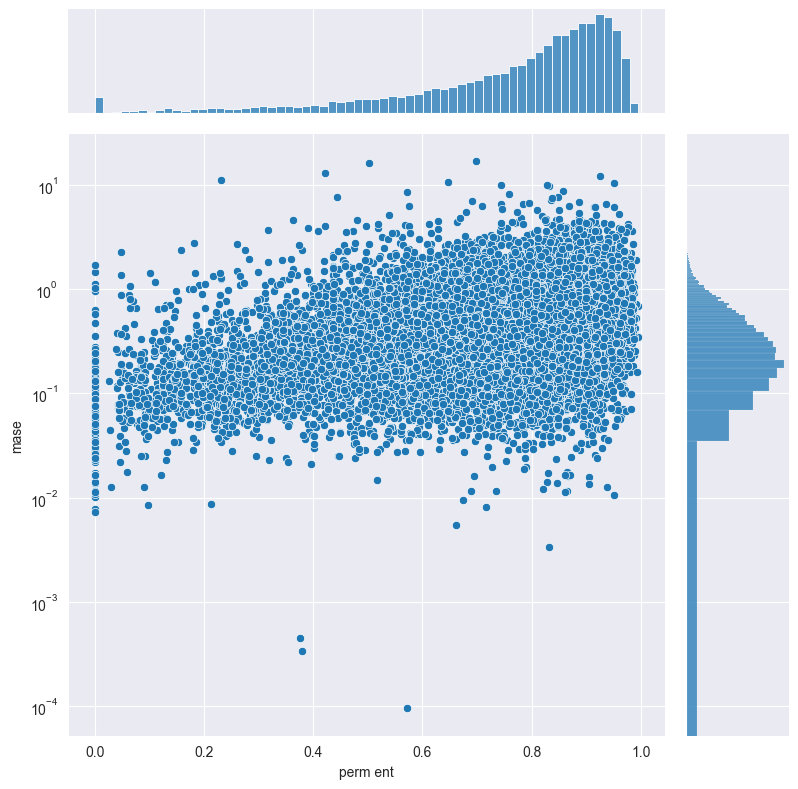

In [105]:
g = sns.JointGrid( x=ent_df["perm_ent4"], y=perm_q['mase'], height=8)
g = g.plot(sns.scatterplot, sns.histplot)
g.ax_marg_y.set_yscale('log')
g.ax_joint.set_xlabel('perm ent')
g.ax_joint.set_ylabel('mase')

Text(65.34722222222221, 0.5, 'mase')

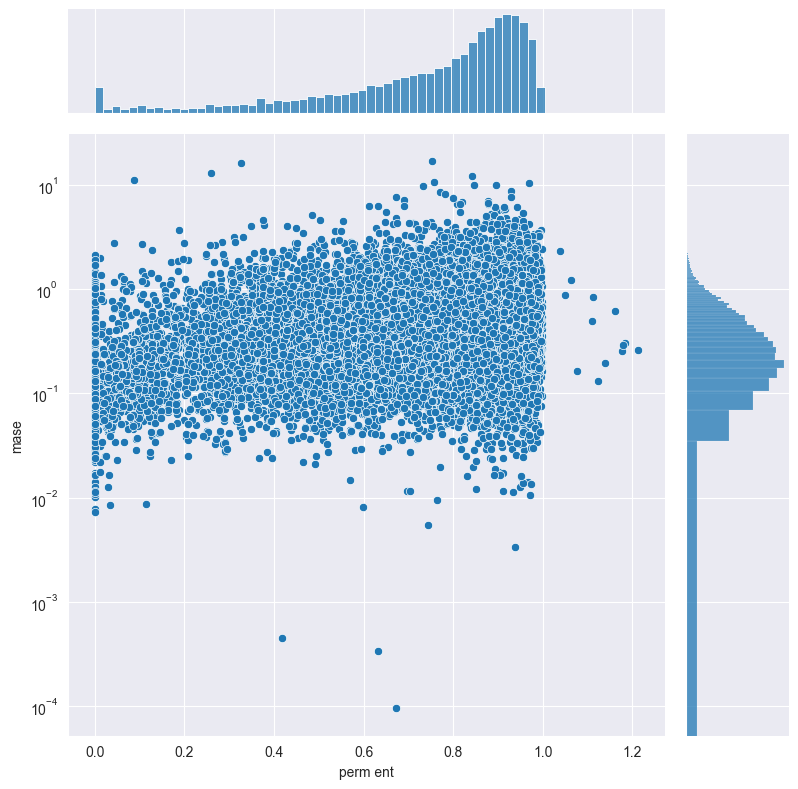

In [106]:
g = sns.JointGrid( x=ent_df["new_ent_rate3"], y=perm_q['mase'], height=8)
g = g.plot(sns.scatterplot, sns.histplot)
g.ax_marg_y.set_yscale('log')
g.ax_joint.set_xlabel('perm ent')
g.ax_joint.set_ylabel('mase')

Text(65.34722222222221, 0.5, 'mase')

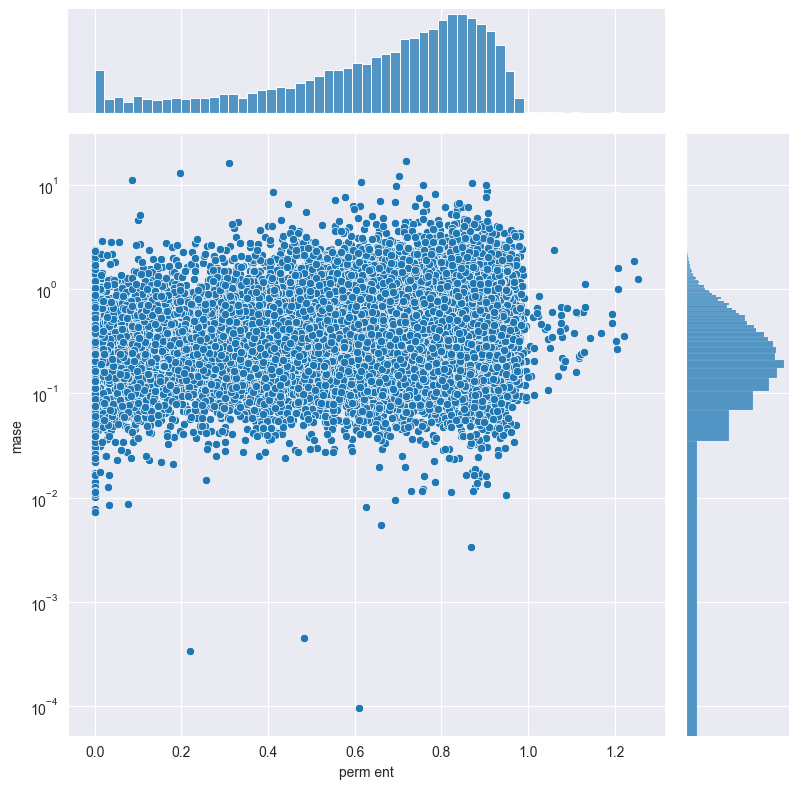

In [107]:
g = sns.JointGrid( x=ent_df["new_ent_rate4"], y=perm_q['mase'], height=8)
g = g.plot(sns.scatterplot, sns.histplot)
g.ax_marg_y.set_yscale('log')
g.ax_joint.set_xlabel('perm ent')
g.ax_joint.set_ylabel('mase')

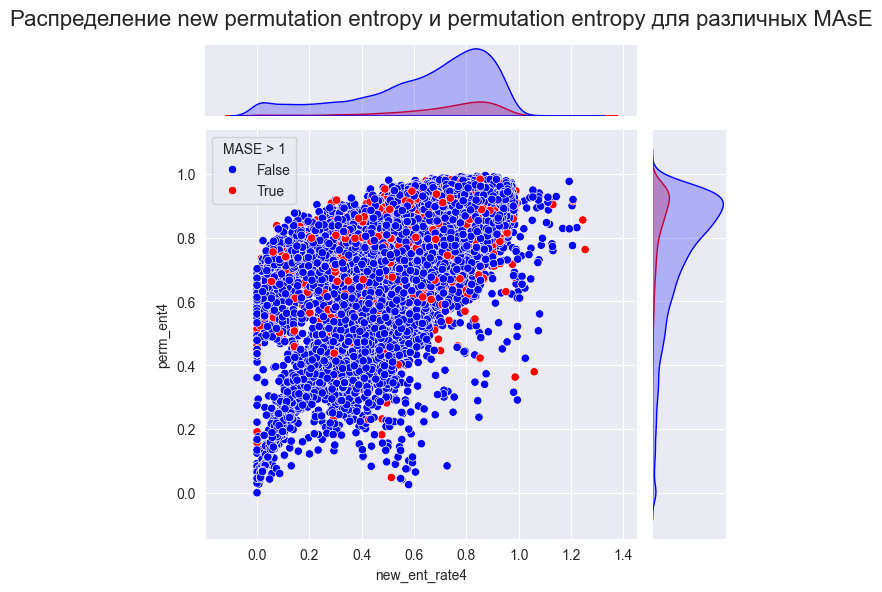

In [108]:
ent_df['MASE > 1'] = perm_q['mase'] > 1
g = sns.jointplot(
    data=ent_df,
    x="new_ent_rate4", y="perm_ent4", hue="MASE > 1",
    kind="scatter", palette={True: "r", False: "b"})
g.fig.suptitle('Распределение new permutation entropy и permutation entropy для различных MAsE', fontsize=16)
g.fig.subplots_adjust(top=0.92)  # Корректировка положения заголовка

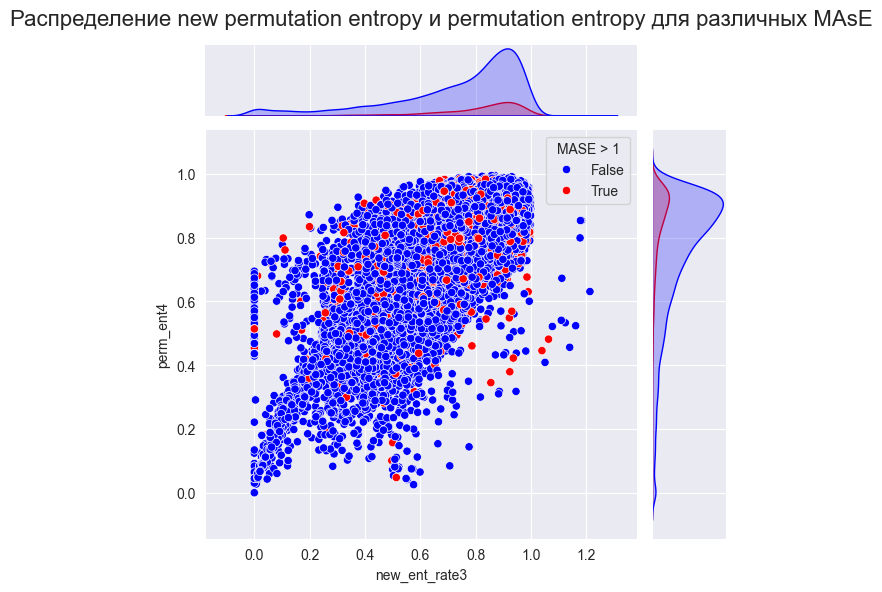

In [109]:
g = sns.jointplot(
    data=ent_df,
    x="new_ent_rate3", y="perm_ent4", hue="MASE > 1",
    kind="scatter", palette={True: "r", False: "b"})
g.fig.suptitle('Распределение new permutation entropy и permutation entropy для различных MAsE', fontsize=16)
g.fig.subplots_adjust(top=0.92)  # Корректировка положения заголовка

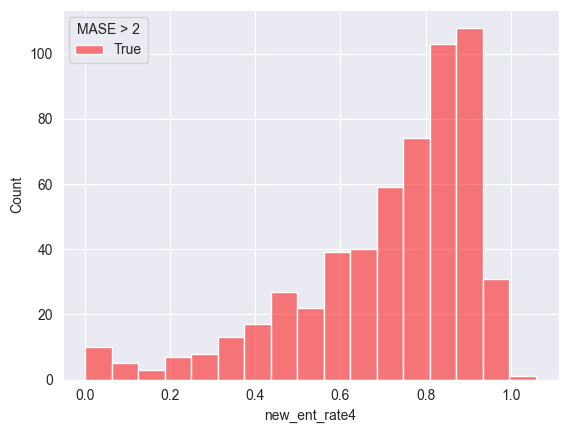

In [110]:
ent_df['MASE > 2'] = perm_q['mase'] > 2
g = sns.histplot(
    data=ent_df[ent_df['MASE > 2']],
    x="new_ent_rate4", hue="MASE > 2",
    palette={True: "r", False: "b"})

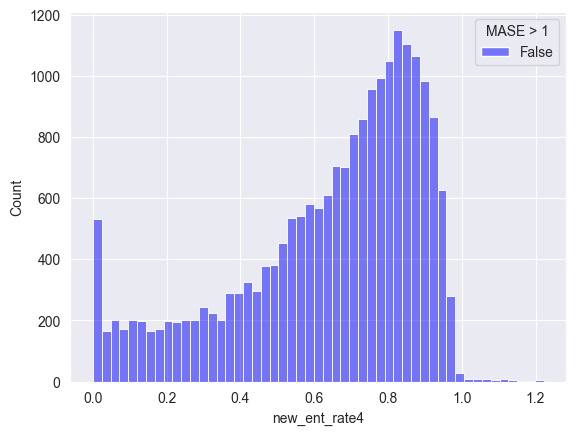

In [112]:
g = sns.histplot(
    data=ent_df[ent_df['MASE > 1'] == False],
    x="new_ent_rate4", hue="MASE > 1",
    palette={True: "r", False: "b"})

In [114]:
ent_df.to_csv("../src/quater_new_ent_rate.csv")